# HW2 - Classification

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [12]:
# Import raw data file

# input_file = "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv"
# df = pd.read_csv(input_file)

# condition = (df["Origin"] == "ORD") # & (df["Reporting_Airline"] == "UA")

# df_filtered = df[condition]

# columns_to_keep = [
#     "CRSDepTime", # [hhmm]
#     # "CRSArrTime",
#     "Distance", # [mile]
#     "CRSElapsedTime", # [min]
#     "ArrDel15" # binary
# ]

# fdata = df_filtered[columns_to_keep].copy()

# for col in columns_to_keep:
#     fdata[col] = pd.to_numeric(fdata[col], errors="coerce")

# fdata = fdata.dropna(subset=columns_to_keep) # delete N/A data

# hours = fdata["CRSDepTime"] // 100 # change "hhmm" to [hrs] of the day
# minutes = fdata["CRSDepTime"] % 100

# fdata["CRSDepTime_hr"] = np.where(
#     fdata["CRSDepTime"] > 0, hours + minutes/60, 0.0
# )

# fdata["CRSElapsedTime_hr"] = np.where(
#     fdata["CRSElapsedTime"] > 0, fdata["CRSElapsedTime"] / 60, 0.0
# )

# fdata.to_csv("dataset_cleaned.csv", index=False)

fdata = pd.read_csv("dataset_cleaned.csv")
print(fdata.head())

   CRSDepTime  Distance  CRSElapsedTime  ArrDel15  CRSDepTime_hr  \
0        1010    4243.0           547.0       0.0      10.166667   
1        1010    4243.0           547.0       0.0      10.166667   
2        1010    4243.0           547.0       0.0      10.166667   
3        1010    4243.0           547.0       1.0      10.166667   
4        1010    4243.0           547.0       0.0      10.166667   

   CRSElapsedTime_hr  
0           9.116667  
1           9.116667  
2           9.116667  
3           9.116667  
4           9.116667  


In [13]:
# Load Data
X_df = fdata[['CRSDepTime_hr', 'Distance', 'CRSElapsedTime_hr']]
y_df = fdata['ArrDel15']

X = X_df.to_numpy()
y = y_df.to_numpy()

# Split Data: Train 80%, Test 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 10,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("")
print("Test dataset class distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

X_train: (19301, 3)
X_test: (4826, 3)
y_train: (19301,)
y_test: (4826,)

Test dataset class distribution:
0.0    0.67385
1.0    0.32615
Name: proportion, dtype: float64


**Dataset Explanation**

The primary objective of this analysis is to investigate the operational factors influencing airplane arrival delays. I define an arrival delay as a delay of 15 minutes or more and classify it as a binary outcome (ArrDel15; 0 = not delayed, 1 = delayed). I hypothesize that its occurance is predominantly associated with scheduled departure time (CRSDepTime), distance (Distance), and scheduled elasped time (CRSElapsedTime). I chose these predictors because they are known in advance, whereas variables such as taxi-out time, actual departure time, and actual flight duration are not available prior to departure.

To reduce variation from other factors, I focuse on a controlled subset of flights departing from Chicago O'Hare International Airport (ORD). In addition, both scheuled departure time and elasped time are converted to hours for easier interpretation.

The dataset was split into training and test sets using an 80/20 ratio. In the test set, 67.4% of the obervations belong to class 0, while 32.6% belong to class 1.

### KNN Model

In [14]:
# KNN model
k = 50

knn = KNeighborsClassifier(k)
knn.fit(X_train, y_train)
y_knn = knn.predict(X_test)

<KNN Classifier>
Test Error Rate: 0.32842934106920846
AUC: 0.5731638510794256
Recall 0.05844980940279543


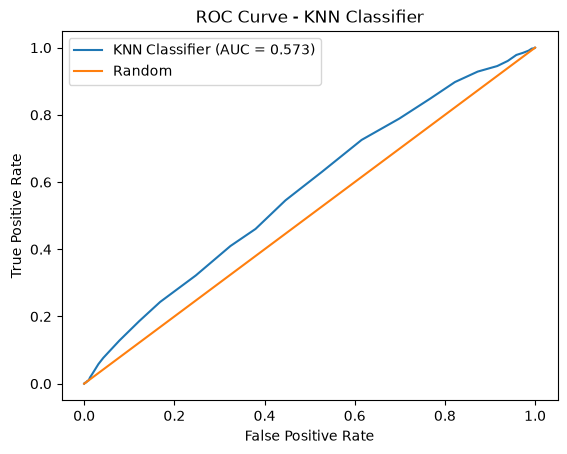

In [15]:
# KNN (1) Test Error Rate
err_knn = np.mean(y_knn != y_test)

# KNN (2) AUC
y_prob = knn.predict_proba(X_test)[:, 1]
auc_knn = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# KNN (3) Recall
recall_knn = recall_score(y_test, y_knn)

print("<KNN Classifier>")
print("Test Error Rate:", err_knn)
print("AUC:", auc_knn)
print("Recall", recall_knn)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"KNN Classifier (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier")
plt.legend()
plt.show()

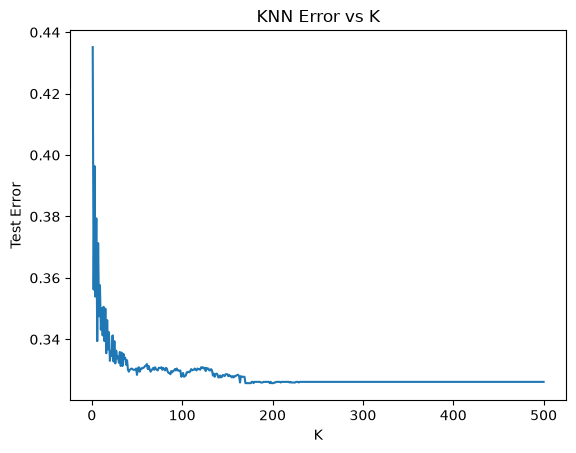

In [16]:
# Analysis of the KNN model as a function of K

k_list = np.linspace(1, 500, 500, dtype=int)
err_list = []

for k in k_list:

    knn = KNeighborsClassifier(k)
    knn.fit(X_train, y_train)
    y_knn = knn.predict(X_test)
    err = np.mean(y_test != y_knn)
    err_list.append(err)

# Plot
plt.plot(k_list, err_list)
plt.xlabel("K")
plt.ylabel("Test Error")
plt.title("KNN Error vs K")
plt.show()

In [17]:
# from sklearn.metrics import mean_squared_error

# k_list = np.linspace(1, 19000, 200, dtype=int)
# mse_list = []

# for k in k_list:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_train, y_train)

#     y_prob = knn.predict_proba(X_test)[:, 1]

#     mse = mean_squared_error(y_test, y_prob)
#     mse_list.append(mse)

# # Plot
# plt.plot(k_list, mse_list)
# plt.xlabel("K")
# plt.ylabel("Test MSE")
# plt.title("KNN Test MSE vs K")
# plt.show()


Result of this code (KNN Test MSE vs K)

![Result of this code (KNN Test MSE vs K)](knn_plot_MSE.png)

**KNN Analysis**

The KNN classifier (K = 50) produced a test error rate of approximately 0.328, which is very close to 0.326, the proportion of class 1 observations in the test set. The AUC of 0.573 is also relatively close to 0.5, indicating limited ability to distinguish between delayed and non-delayed flights. Because the dataset is imbalanced, the test error rate alone may not adequately represent the model's performance. Therefore, recall was also considered to evaluate how well the model identifies actual delayed flights; the very low recall of 0.0584 indicates that KNN fails to idenify most of the delayed flights.

As K increases, the test error rate decreases rapidly at first and then gradually stabilizes around 0.33. Even when K approaches 19,000, which is close to the total number of training set, the error rate remains near 0.33 rather than showing a clear U-shaped pattern. The probability-based test MSE shows a similar trend: after a sharp initial decreases, it reachers a mininum at relatively small K and then increases only slightly as K becomes larger. This weak pattern my indicate that the selected predictors contain limited information for distinguishing delayed from non-delayed flights. In addition, the class imbalance may cause large-K KNN models to increasingly reflect the overall class proportions rather than the local patterns in the predictors.

### Logistic Regression Model

Logistic Regression
Test Error Rate: 0.32615002072109406
AUC: 0.5790964723497298
Recall 0.0

Max of y_prob: 0.45588366102711075


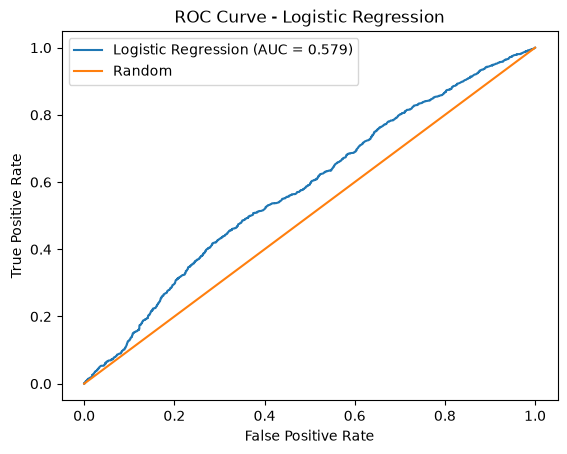

In [18]:
# Logistic Regression
LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)
y_LR = LR_model.predict(X_test)

# LR (1) Test Error Rate
err_LR = np.mean(y_LR != y_test)

# LR (2) AUC
y_prob_LR = LR_model.predict_proba(X_test)[:, 1]
auc_LR = roc_auc_score(y_test, y_prob_LR)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_LR)

# LR (3) Recall
recall_LR = recall_score(y_test, y_LR)

print("Logistic Regression")
print("Test Error Rate:", err_LR)
print("AUC:", auc_LR)
print("Recall", recall_LR)

print("")
print("Max of y_prob:", max(y_prob_LR))

# Plot ROC curve
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_LR:.3f})")
plt.plot([0, 1], [0, 1], label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

**Analysis of Logistic Regression**

The logistic regression model produced a test error rate of 0.326, which is nearly identical to the proportion of class 1 observations in the test set (0.326). The AUC of 0.580 is also relatively close to 0.5, indicating limited ability to distinguish between delayed and non-delyaed flights. In addition, the recall is 0.0, meaning that the model fails to classify any of the actual delayed flights as delayed. The maximum predicted probability of class 1 is approximately 0.456, which is below the default classification threshold of 0.5. Therefore, the model classified all test observations as non-delayed (class 0), the majority class in the dataset. Consistent with the AUC value, the ROC curve lies relatively close to the random-classifier diagonal, further indicating limited discriminative ability.

### Linear Discriminant Analysis

Linear Discriminant Analysis
Test Error Rate: 0.32615002072109406
AUC: 0.578809091775797
Recall: 0.0

Max of y_prob: 0.45613504288227913


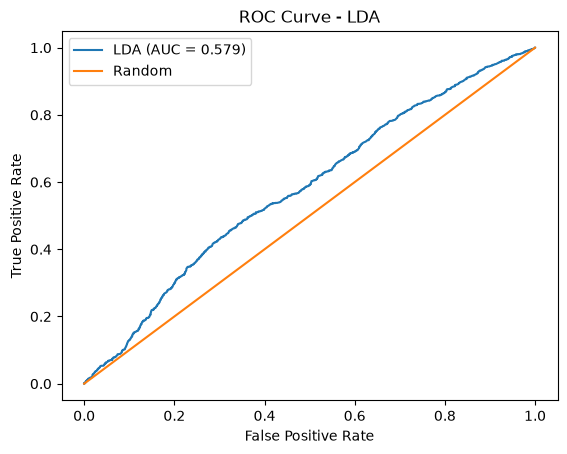

In [19]:
# LDA
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(X_train, y_train)
y_LDA = LDA_model.predict(X_test)

# LDA (1) Test Error Rate
err_LDA = np.mean(y_LDA != y_test)

# LDA (2) AUC
y_prob_LDA = LDA_model.predict_proba(X_test)[:, 1]
auc_LDA = roc_auc_score(y_test, y_prob_LDA)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_LDA)

# LDA (3) Recall
recall_LDA = recall_score(y_test, y_LDA)

print("Linear Discriminant Analysis")
print("Test Error Rate:", err_LDA)
print("AUC:", auc_LDA)
print("Recall:", recall_LDA)

print("")
print("Max of y_prob:", max(y_prob_LDA))

# Plot ROC curve
plt.plot(fpr, tpr, label=f"LDA (AUC = {auc_LDA:.3f})")
plt.plot([0, 1], [0, 1], label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LDA")
plt.legend()
plt.show()

**Analysis of LDA**

The results are almost identical to those of logistic regression. the test error rate is exactly the same because both models classified all test observations as class 0.

In [20]:
print("KNN Classifier")
print("Test Error Rate:", err_knn)
print("AUC:", auc_knn)
print("Recall", recall_knn)

print()

print("Logistic Regression")
print("Test Error Rate:", err_LR)
print("AUC:", auc_LR)
print("Recall", recall_LR)

print()

print("Linear Discriminant Analysis")
print("Test Error Rate:", err_LDA)
print("AUC:", auc_LDA)
print("Recall:", recall_LDA)

KNN Classifier
Test Error Rate: 0.32842934106920846
AUC: 0.5731638510794256
Recall 0.05844980940279543

Logistic Regression
Test Error Rate: 0.32615002072109406
AUC: 0.5790964723497298
Recall 0.0

Linear Discriminant Analysis
Test Error Rate: 0.32615002072109406
AUC: 0.578809091775797
Recall: 0.0


### Overall Analysis

Overall, both KNN, logistic regression and LDA showed limited ability to distinguish between delayed and non-delayed flights, suggesting that the selected predictors may not contain sufficient information to accurately predict arrival delays. To investigate possible reasons for the limited model performance, I conducted the following additional analyses:

- Correlation: Distance and CRSElapsedTime are correlated. However, removing Distance did not result in a meaningful change in model performance.
- Scaling: Since the predictors have different units and scales (miles and hours), standardization was also tested, but it also did not meaningfully improve the results.

Therefore, future analysis should consider additional predictors that are known before departure and may provide stronger predictive information about arrival delays.


# Problem 3 solution

![Problem 3 solution](hw2_prob3.jpg)